# Chapter 4 — Business Problems and Data Science Solutions

**Course 888102 — International College of Digital Innovation, Chiang Mai University**

> *A business situation cannot be ignored — data science is how you deal with it systematically.*

Chapters 1–3 were about the material: what data is, what makes it big, whether it can be trusted. This
chapter is about the **work**. It answers three questions that every project has to answer before a single
line of modeling code is written:

1. What problem are we actually solving, and how will we know if we solved it?
2. What process do we follow, so the project is repeatable rather than heroic?
3. Which *kind* of technique does this problem call for?

### Learning objectives

By the end of this chapter you should be able to:

1. **Business problems** — recognize an issue, a threat, or an opportunity, and write a three-part problem
   statement with measurable success criteria.
2. **The data science process** — describe CRISP-DM's six phases, what each produces, and why it loops.
3. **Data mining tasks** — name the nine tasks and pick the right one for a given question.
4. **Industry applications** — recognize how the same nine tasks reappear across every field.

### How this notebook is organized

| Section | What it covers |
|---|---|
| 1 | Business problems and problem statements |
| 2 | CRISP-DM, walked end to end on a real (small) project |
| 3 | The nine data mining tasks, each demonstrated in code |
| 4 | Choosing the right task for a question |
| 5 | Industry applications |
| 6–8 | Glossary, self-check quiz, summary |
| 9 | Graded homework 📝 |

In [1]:
# Run this cell first — everything below depends on it.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# The chapter's headline examples all draw from this one generator, in a fixed order,
# so that the numbers here match the numbers on the lecture slides exactly.
rng = np.random.default_rng(888102)

# Extra illustrations further down use their own generators, so that adding one
# never shifts the headline numbers above it.
print("Ready. pandas", pd.__version__, "| networkx", nx.__version__)

Ready. pandas 3.0.5 | networkx 3.6.1


---
## 1. What is a business problem?

A **business problem** is a situation that cannot be ignored and must be systematically dealt with. It comes
in three flavors, and telling them apart matters because they call for different urgency and different
evidence:

| Kind | What it is | Examples from the lecture |
|---|---|---|
| **An issue** | Something already going wrong, inside the organization | Unhappy employees, delayed launches, customer churn, declining revenue, operational inefficiency |
| **A threat** | Something outside that could go wrong | Shrinking market, unfavorable regulations, new competitors, altered purchasing tendencies |
| **An opportunity** | Something outside you could benefit from | Market growth, favorable regulations, a new location, a new customer segment, a new distribution channel |

Issues are the easiest to get funded and the least valuable to solve — by the time an issue is visible, you
are already losing. Opportunities are the hardest to argue for and where most of the upside lives.

### 1.1 A good business problem statement has three parts

| Step | Component | What it captures |
|---|---|---|
| 1 | **Current state** | The existing environment: what, when, where, and why the problem occurs, and its impact on stakeholders |
| 2 | **Business objective** | The desired state, and the main requirements needed to achieve it |
| 3 | **Success criteria** | How progress toward the objective will be measured |

Without all three, a problem statement is too vague to act on. The third is the one people skip, and skipping
it is how projects run for a year without anyone being able to say whether they worked.

In [2]:
# The lecture's worked example, as a small reusable record.
cross_sales_problem = {
    "title": "Improving cross sales",
    "current_state": ("Customer satisfaction surveys show shoppers struggle to find items they normally "
                      "purchase together, which is hurting cross sales."),
    "objective": ("Redesign the store layout so customers can easily locate items they normally "
                  "buy together."),
    "success_criteria": "Cross-sales increase by 10% within three months of the redesigned layout.",
}

for key, value in cross_sales_problem.items():
    print(f"{key.upper().replace('_', ' ')}:\n  {value}\n")

TITLE:
  Improving cross sales

CURRENT STATE:
  Customer satisfaction surveys show shoppers struggle to find items they normally purchase together, which is hurting cross sales.

OBJECTIVE:
  Redesign the store layout so customers can easily locate items they normally buy together.

SUCCESS CRITERIA:
  Cross-sales increase by 10% within three months of the redesigned layout.



**How to read it:** the success criterion is **measurable** — "10% within three months" — not vague ("sales
should go up"). That single sentence is what turns an opinion into something a data science project can test,
and it is what the Evaluation phase of CRISP-DM will be judged against.

### 1.2 Making success criteria testable: the SMART check

A criterion is usable when it is **S**pecific, **M**easurable, **A**chievable, **R**elevant, and
**T**ime-bound. The two failure modes are opposite and equally common: criteria so vague nobody can fail
them, and criteria so precise they measure the wrong thing.

In [3]:
statements = pd.DataFrame([
    ("Improve customer satisfaction.",
     "No", "No", "?", "Yes", "No",
     "Nothing here can ever be checked."),
    ("Achieve 95% model accuracy.",
     "Yes", "Yes", "?", "No", "No",
     "Measurable, but accuracy is not a business outcome — see Section 2.5."),
    ("Increase cross-sales by 10% within three months of the layout change.",
     "Yes", "Yes", "Yes", "Yes", "Yes",
     "Usable: a number, a deadline, and a business outcome."),
    ("Reduce monthly churn from 4.2% to below 3.5% by the end of Q3, without cutting price.",
     "Yes", "Yes", "Yes", "Yes", "Yes",
     "Usable, and it names a constraint the solution must respect."),
], columns=["Success criterion", "S", "M", "A", "R", "T", "Verdict"])

statements

,Success criterion,S,M,A,R,T,Verdict
0,Improve customer satisfaction.,No,No,?,Yes,No,Nothing here can ever be checked.
1,Achieve 95% model accuracy.,Yes,Yes,?,No,No,"Measurable, but accuracy is not a business out..."
2,Increase cross-sales by 10% within three month...,Yes,Yes,Yes,Yes,Yes,"Usable: a number, a deadline, and a business o..."
3,Reduce monthly churn from 4.2% to below 3.5% b...,Yes,Yes,Yes,Yes,Yes,"Usable, and it names a constraint the solution..."


**How to read it:** the second row is the trap worth memorizing. *"Achieve 95% model accuracy"* is specific,
measurable, and time-boundable — and it is still a bad success criterion, because it is **not relevant**: it
measures the model rather than the business. Section 2.5 shows a model that hits a superb technical score
while being useless in practice.

Note also the fourth row's constraint: *"without cutting price."* Real objectives almost always have one, and
writing it down early prevents the classic outcome where a team delivers exactly what was asked and it is
rejected for a reason nobody had stated.

In [4]:
# A small check you can run against any problem statement.
REQUIRED = ["current_state", "objective", "success_criteria"]
MEASURE_HINTS = ["%", "percent", "by ", "within", "baht", "reduce", "increase", "below", "above"]

def check_problem_statement(statement):
    problems = []
    for field in REQUIRED:
        if not statement.get(field, "").strip():
            problems.append(f"missing '{field}'")
    criteria = statement.get("success_criteria", "").lower()
    if criteria and not any(hint in criteria for hint in MEASURE_HINTS):
        problems.append("success criteria has no measurable quantity or deadline")
    if not any(char.isdigit() for char in criteria):
        problems.append("success criteria contains no number")
    return problems or ["OK — all three parts present and the criteria look measurable"]

vague = {"title": "Fix the app",
         "current_state": "Users complain.",
         "objective": "Make the app better.",
         "success_criteria": "Users should be happier."}

for name, statement in [("Cross sales", cross_sales_problem), ("Vague version", vague)]:
    print(f"{name}:")
    for line in check_problem_statement(statement):
        print(f"  - {line}")
    print()

Cross sales:
  - OK — all three parts present and the criteria look measurable

Vague version:
  - success criteria has no measurable quantity or deadline
  - success criteria contains no number



> ✏️ **Try it:** write your own three-part `dict` for the lecture's **property valuation** example — current
> state: "market share is around 15%, and our estimates land within 10% of the eventual sale price only 70%
> of the time"; objective: "increase market share through more reliable valuations"; success criteria:
> "market share reaches 20% next financial year." Run it through `check_problem_statement`. Then try to make
> the success criteria *better* by adding the accuracy target as well as the market-share target — why might
> a project need two?

---
## 2. CRISP-DM — a standard process for data science

A standard process must be **reliable and repeatable**. **CRISP-DM** — the CRoss Industry Standard Process
for Data Mining — describes the data science life cycle in six phases, each answering one question:

| Phase | Key question | What it produces |
|---|---|---|
| 1. **Business understanding** | What does the business need? | A problem statement, success criteria, a project plan |
| 2. **Data understanding** | What data do we have or need? Is it clean? | A described, explored, quality-checked dataset |
| 3. **Data preparation** | How do we organize the data for modeling? | A clean, modeling-ready table |
| 4. **Modeling** | What modeling techniques should we apply? | One or more trained models |
| 5. **Evaluation** | Which model best meets the business objectives? | A go / iterate / stop decision |
| 6. **Deployment** | How do stakeholders access the results? | Something people actually use, plus monitoring |

### What each phase actually involves

**Phase 1 — Business understanding.** Determine the business question and success criteria (KPI). Assess
resources, risks, and cost-benefit. Set technical goals. Write a project plan.

**Phase 2 — Data understanding.** Collect the data. Describe its format, rows, columns, and available
features. Explore relationships and visualize it. Verify data quality.

**Phase 3 — Data preparation.** Select the dataset, columns, and rows to use. Clean the data
(*garbage in, garbage out*). Engineer new features. Integrate and format as needed.

**Phase 4 — Modeling.** Select which algorithms to try. Design the train/test/validation split. Develop the
model. Assess it against technical success metrics.

**Phase 5 — Evaluation.** Would the model meet the *business* success criteria? Review the process — was
anything missed? Decide: deploy, iterate, or start a new project.

**Phase 6 — Deployment.** Plan how the model is delivered. Monitor and maintain model quality over time.
Write a final report and review what could improve.

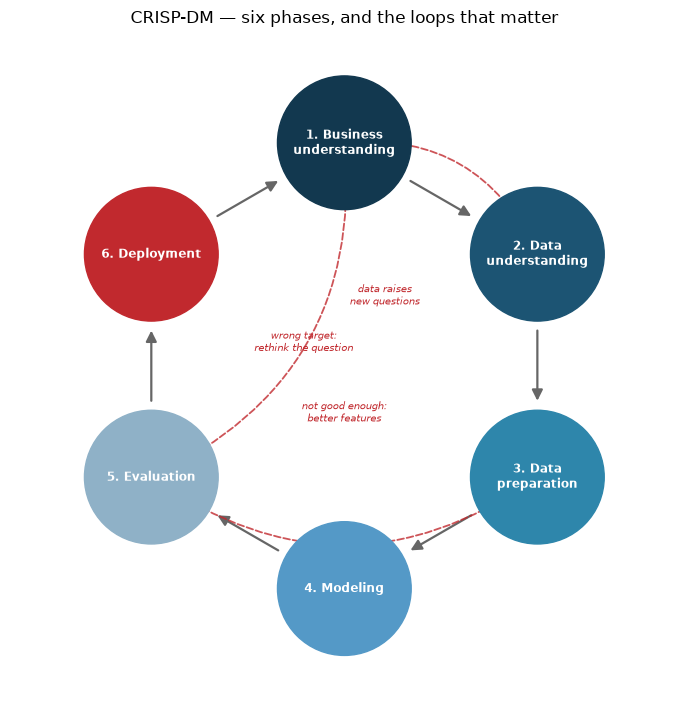

In [5]:
# CRISP-DM is a cycle, not a line. Drawing it makes the loop-backs visible.
from matplotlib.patches import FancyArrowPatch, Circle

phases = ["1. Business\nunderstanding", "2. Data\nunderstanding", "3. Data\npreparation",
          "4. Modeling", "5. Evaluation", "6. Deployment"]
angles = np.linspace(np.pi / 2, np.pi / 2 - 2 * np.pi, len(phases), endpoint=False)
positions = [(np.cos(a), np.sin(a)) for a in angles]

fig, ax = plt.subplots(figsize=(7.6, 7.2))
colors = ["#12384f", "#1c5473", "#2E86AB", "#5499C7", "#8FB1C7", "#C1292E"]

for (x, y), label, color in zip(positions, phases, colors):
    ax.add_patch(Circle((x, y), 0.30, color=color, zorder=2))
    ax.text(x, y, label, ha="center", va="center", color="white",
            fontsize=8.5, fontweight="bold", zorder=3)

# The main forward cycle.
for i in range(len(phases)):
    start, end = np.array(positions[i]), np.array(positions[(i + 1) % len(phases)])
    direction = end - start
    direction = direction / np.linalg.norm(direction)
    ax.add_patch(FancyArrowPatch(start + direction * 0.33, end - direction * 0.33,
                                 arrowstyle="-|>", mutation_scale=16,
                                 color="#666", linewidth=1.6, zorder=1))

# The loop-backs that make CRISP-DM iterative rather than a waterfall.
loopbacks = [(1, 0, "data raises\nnew questions"), (4, 2, "not good enough:\nbetter features"),
             (4, 0, "wrong target:\nrethink the question")]
for source, target, note in loopbacks:
    start, end = np.array(positions[source]), np.array(positions[target])
    ax.add_patch(FancyArrowPatch(start, end, connectionstyle="arc3,rad=0.35",
                                 arrowstyle="-|>", mutation_scale=13, linestyle="--",
                                 color="#C1292E", linewidth=1.3, alpha=0.8, zorder=1))
    mid = (start + end) / 2
    ax.text(mid[0] * 0.42, mid[1] * 0.42, note, fontsize=7, color="#C1292E",
            ha="center", va="center", style="italic")

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect("equal")
ax.axis("off")
ax.grid(False)
ax.set_title("CRISP-DM — six phases, and the loops that matter", fontsize=12)
plt.show()

**How to read it:** the gray arrows are the happy path everyone draws. The dashed red arrows are what
actually happens, and they are the reason CRISP-DM is a *cycle* rather than a waterfall:

- **Data understanding → business understanding.** You look at the data and discover the question was wrong,
  or unanswerable with what exists.
- **Evaluation → data preparation.** The model is not good enough, and the fix is usually a better feature
  rather than a fancier algorithm.
- **Evaluation → business understanding.** The model works and does not help, because it was aimed at the
  wrong target.

The third loop-back is the expensive one, and it is prevented in Phase 1, not detected in Phase 5.

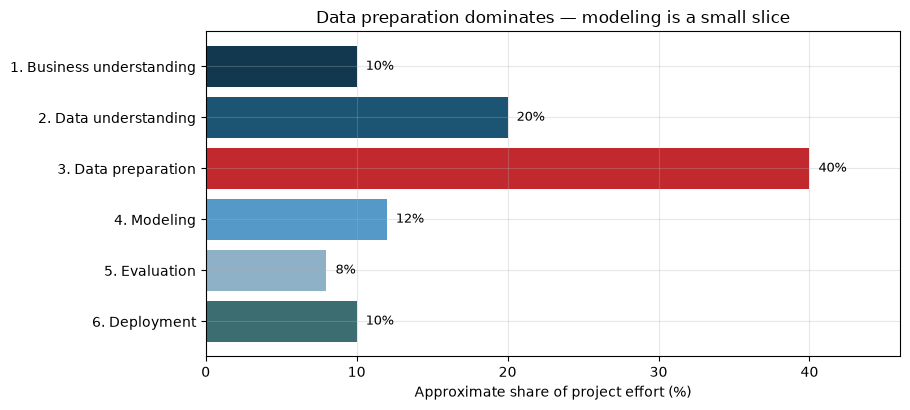

In [6]:
# Where the time actually goes. These proportions are widely reported and rarely believed by beginners.
effort = pd.Series({
    "1. Business understanding": 10,
    "2. Data understanding": 20,
    "3. Data preparation": 40,
    "4. Modeling": 12,
    "5. Evaluation": 8,
    "6. Deployment": 10,
})

fig, ax = plt.subplots(figsize=(9.2, 4.2))
colors = ["#12384f", "#1c5473", "#C1292E", "#5499C7", "#8FB1C7", "#3C6E71"]
bars = ax.barh(effort.index[::-1], effort.values[::-1], color=colors[::-1])
for bar, value in zip(bars, effort.values[::-1]):
    ax.text(value + 0.6, bar.get_y() + bar.get_height() / 2, f"{value}%", va="center", fontsize=9)
ax.set_xlabel("Approximate share of project effort (%)")
ax.set_title("Data preparation dominates — modeling is a small slice")
ax.set_xlim(0, 46)
plt.show()

**How to read it:** the phase most people imagine data science *is* — modeling — takes roughly an eighth of
the effort. Understanding and preparing the data takes about **60%**. These figures are approximate and vary
by project, but the ordering is remarkably stable across surveys and worth internalizing early: if you enjoy
only the modeling part, you will enjoy about one day a week.

This is also why Chapter 6 (Data Preparation) is one of the longest chapters in the course.

### 2.1 Worked example — flagging at-risk students, end to end

**Business question:** which students are at risk of failing, so instructors can reach out early?

We will walk all six phases. Watch what each phase hands to the next.

In [7]:
# PHASE 1 — BUSINESS UNDERSTANDING: the question, the criteria, and the constraints.
project = {
    "business_question": "Which students are at risk of failing, so instructors can reach out early?",
    "success_criteria": "Flag at least 80% of eventually-failing students using only mid-course data.",
    "constraint": "Instructors can follow up with at most 10 students, so precision matters too.",
    "stakeholder": "Course instructors",
    "risk": "Flagging a student who was fine wastes instructor time and may discourage the student.",
}
for key, value in project.items():
    print(f"{key.replace('_', ' ').title():20s}: {value}")

Business Question   : Which students are at risk of failing, so instructors can reach out early?
Success Criteria    : Flag at least 80% of eventually-failing students using only mid-course data.
Constraint          : Instructors can follow up with at most 10 students, so precision matters too.
Stakeholder         : Course instructors
Risk                : Flagging a student who was fine wastes instructor time and may discourage the student.


Note the **constraint** and the **risk**. Neither is in the lecture's version, and both change the project.
"Flag 80% of failing students" can be achieved trivially by flagging everybody — which is exactly why a real
Phase 1 records what it would cost to be wrong.

In [8]:
# PHASE 2 — DATA UNDERSTANDING: collect the data and describe it before touching it.
students = pd.DataFrame({
    "student_id": range(1, 21),
    "quiz_avg": rng.uniform(40, 100, 20).round(1),
    "forum_posts": rng.integers(0, 15, 20),
})
# Ground truth for this toy example: students pass if their quiz average is high enough.
students["passed"] = students["quiz_avg"] >= 60

print(students[["quiz_avg", "forum_posts"]].describe().round(1).to_string())
print(f"\nRows: {len(students)}   Missing values: {students.isna().sum().sum()}")
print(f"Passed: {students['passed'].sum()}   Failed: {(~students['passed']).sum()}")

       quiz_avg  forum_posts
count      20.0         20.0
mean       69.6          8.5
std        17.4          4.3
min        43.3          1.0
25%        53.7          6.2
50%        69.3          9.0
75%        79.8         12.0
max        96.7         14.0

Rows: 20   Missing values: 0
Passed: 13   Failed: 7


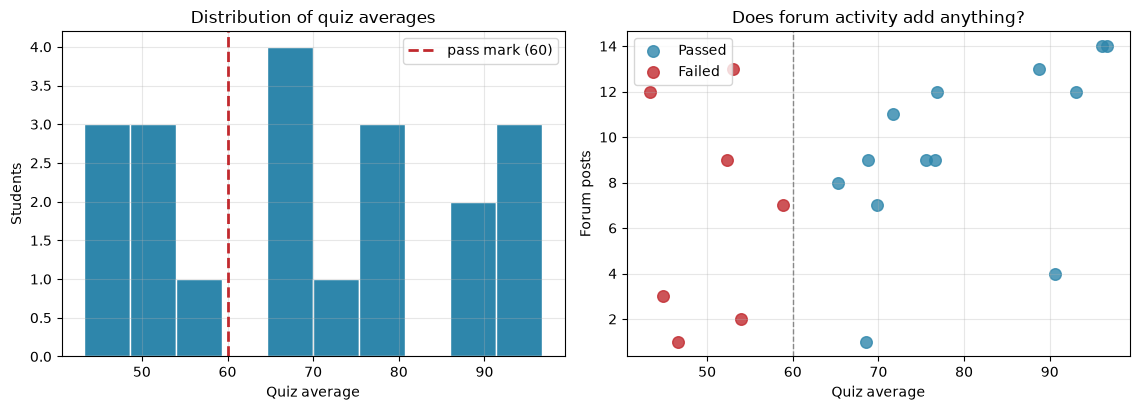

Correlation, forum_posts vs quiz_avg: +0.47


In [9]:
# Data understanding also means LOOKING at it, not just describing it.
fig, (ax_hist, ax_scatter) = plt.subplots(1, 2, figsize=(11.5, 4.2))

ax_hist.hist(students["quiz_avg"], bins=10, color="#2E86AB", edgecolor="white")
ax_hist.axvline(60, color="#C1292E", linestyle="--", linewidth=2, label="pass mark (60)")
ax_hist.set_xlabel("Quiz average")
ax_hist.set_ylabel("Students")
ax_hist.set_title("Distribution of quiz averages")
ax_hist.legend()

for passed, color, label in [(True, "#2E86AB", "Passed"), (False, "#C1292E", "Failed")]:
    subset = students[students["passed"] == passed]
    ax_scatter.scatter(subset["quiz_avg"], subset["forum_posts"], color=color, s=70,
                       alpha=0.8, label=label)
ax_scatter.axvline(60, color="#888", linestyle="--", linewidth=1)
ax_scatter.set_xlabel("Quiz average")
ax_scatter.set_ylabel("Forum posts")
ax_scatter.set_title("Does forum activity add anything?")
ax_scatter.legend()

plt.show()

print(f"Correlation, forum_posts vs quiz_avg: {students['forum_posts'].corr(students['quiz_avg']):+.2f}")

**How to read it:** the scatter is the useful panel, and it delivers a genuinely useful negative result. The
red and blue points separate cleanly left-to-right (by quiz average) and not at all vertically (by forum
posts). **Forum activity carries no signal here.**

Finding that out in Phase 2 costs five minutes. Finding it out in Phase 4, after building a model around it,
costs a week. This is what "explore relationships, visualize it" in the phase description is for.

In [10]:
# PHASE 3 — DATA PREPARATION: engineer the feature the model will use.
students["at_risk_flag"] = students["quiz_avg"] < 60

print("Engineered feature 'at_risk_flag' (quiz_avg < 60):")
print(students[["student_id", "quiz_avg", "forum_posts", "at_risk_flag", "passed"]].head(8).to_string(index=False))

Engineered feature 'at_risk_flag' (quiz_avg < 60):
 student_id  quiz_avg  forum_posts  at_risk_flag  passed
          1      71.7           11         False    True
          2      96.7           14         False    True
          3      68.8            9         False    True
          4      75.5            9         False    True
          5      76.6            9         False    True
          6      93.1           12         False    True
          7      88.8           13         False    True
          8      76.8           12         False    True


In [11]:
# PHASE 4 — MODELING: the simplest thing that could possibly work — a rule-based classifier.
threshold = 60
students["predicted_at_risk"] = students["quiz_avg"] < threshold

print(f"Model: predict at-risk if quiz_avg < {threshold}")
print(f"Flagged: {students['predicted_at_risk'].sum()} of {len(students)} students")

Model: predict at-risk if quiz_avg < 60
Flagged: 7 of 20 students


**A note on starting simple.** A one-line threshold rule is a legitimate first model, and skipping it is a
common beginner mistake. It gives you a **baseline**: any fancier model must beat it, and often does not. It
also runs instantly, is explainable to an instructor in one sentence, and cannot overfit.

In [12]:
# PHASE 5 — EVALUATION: does the model meet the BUSINESS success criteria?
actually_failed = ~students["passed"]
predicted = students["predicted_at_risk"]

true_positive = (predicted & actually_failed).sum()
false_positive = (predicted & ~actually_failed).sum()
false_negative = (~predicted & actually_failed).sum()
true_negative = (~predicted & ~actually_failed).sum()

recall = true_positive / (true_positive + false_negative)
precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) else np.nan
accuracy = (true_positive + true_negative) / len(students)

print(f"Students who actually failed : {actually_failed.sum()}")
print(f"Correctly flagged            : {true_positive}")
print(f"\nRecall    {recall:.0%}   (target was 80%)   <- did we catch the failing students?")
print(f"Precision {precision:.0%}                      <- were the ones we flagged really at risk?")
print(f"Accuracy  {accuracy:.0%}")
print("\n" + ("MEETS the success criteria." if recall >= 0.80 else "Does NOT meet the criteria — iterate."))
print(f"Instructors must contact {predicted.sum()} students; the constraint allows 10.")

Students who actually failed : 7
Correctly flagged            : 7

Recall    100%   (target was 80%)   <- did we catch the failing students?
Precision 100%                      <- were the ones we flagged really at risk?
Accuracy  100%

MEETS the success criteria.
Instructors must contact 7 students; the constraint allows 10.


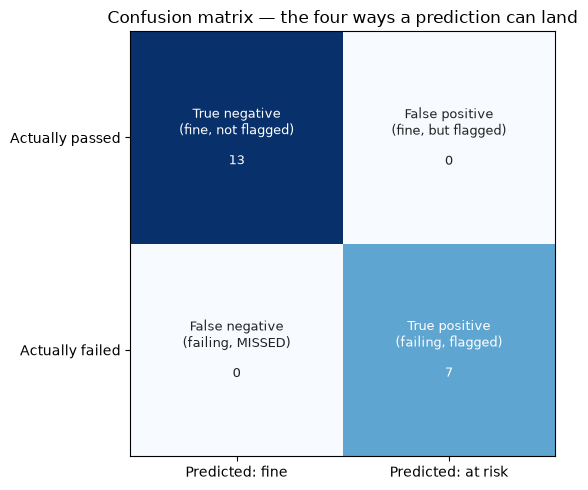

In [13]:
# The confusion matrix — the picture behind those four numbers.
matrix = np.array([[true_negative, false_positive],
                   [false_negative, true_positive]])

fig, ax = plt.subplots(figsize=(6.2, 5))
image = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=matrix.max())
labels = [["True negative\n(fine, not flagged)", "False positive\n(fine, but flagged)"],
          ["False negative\n(failing, MISSED)", "True positive\n(failing, flagged)"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{labels[i][j]}\n\n{matrix[i, j]}", ha="center", va="center",
                fontsize=9, color="white" if matrix[i, j] > matrix.max() / 2 else "#222")
ax.set_xticks([0, 1], ["Predicted: fine", "Predicted: at risk"])
ax.set_yticks([0, 1], ["Actually passed", "Actually failed"])
ax.set_title("Confusion matrix — the four ways a prediction can land")
ax.grid(False)
plt.show()

**How to read it:** the diagonal from top-left to bottom-right is where the model was right. The other two
cells are the two *different* mistakes, and they cost different things:

- A **false negative** is a struggling student nobody contacted. That is the expensive error here.
- A **false positive** is a fine student who got an unnecessary email. Mildly annoying, and it consumes one
  of the ten follow-up slots.

Because the model is a threshold on exactly the variable that defines passing, it is perfect on this toy
data. Real data is never this kind, and **which error you would rather make** is a business decision, not a
technical one. Section 2.5 pushes on that.

In [14]:
# PHASE 6 — DEPLOYMENT: package it as something an instructor can actually run.
def flag_at_risk_students(df, quiz_col="quiz_avg", id_col="student_id", threshold=60, top_n=10):
    # Return the students most at risk, worst first, capped at what instructors can follow up on.
    at_risk = df.loc[df[quiz_col] < threshold, [id_col, quiz_col]]
    return at_risk.sort_values(quiz_col).head(top_n).reset_index(drop=True)

contact_list = flag_at_risk_students(students)
print("Instructors should contact these students, worst first:")
print(contact_list.to_string(index=False))
print(f"\n({len(contact_list)} students, within the limit of 10.)")

Instructors should contact these students, worst first:
 student_id  quiz_avg
         19      43.3
         11      44.9
         10      46.6
         12      52.3
         17      53.0
         15      53.9
         20      58.9

(7 students, within the limit of 10.)


**How to read it:** deployment is where the constraint from Phase 1 finally gets honored. The function does
not just return a set of flags — it **ranks** them and caps the list at what instructors can actually act on.
A model whose output nobody can use has not been deployed, however good its metrics.

Deployment also means **monitoring**. The threshold of 60 was tuned on one cohort; if next semester's quizzes
are harder, the same threshold flags half the class. Section 2.6 covers that.

### 2.5 When a great metric hides a useless model

Consider a different version of the same problem, where failing is rare. This is the single most common
evaluation mistake in practice, and it is worth seeing once, painfully.

In [15]:
rng_rare = np.random.default_rng(7)          # its own generator — see the setup cell

n = 1_000
failed = rng_rare.random(n) < 0.03           # only 3% of students actually fail

# A "model" that never flags anybody.
predict_nothing = np.zeros(n, dtype=bool)

accuracy = (predict_nothing == failed).mean()
tp = (predict_nothing & failed).sum()
recall = tp / failed.sum()

print(f"Failing students: {failed.sum()} of {n} ({failed.mean():.1%})")
print(f"\nModel: 'nobody is at risk'")
print(f"  Accuracy : {accuracy:.1%}   <- looks excellent")
print(f"  Recall   : {recall:.0%}     <- catches nobody at all")
print("\nThe model has learned nothing and would pass an accuracy-based success criterion.")

Failing students: 25 of 1000 (2.5%)

Model: 'nobody is at risk'
  Accuracy : 97.5%   <- looks excellent
  Recall   : 0%     <- catches nobody at all

The model has learned nothing and would pass an accuracy-based success criterion.


**How to read it:** 97.5% accuracy, achieved by a model that is a single constant. This is the **class
imbalance** trap, and it is why *"achieve 95% model accuracy"* failed the Relevance test back in Section 1.2.

The fix is to choose the metric from the business consequence:

| Metric | Question it answers | Use it when |
|---|---|---|
| **Accuracy** | What fraction of all predictions were right? | Classes are balanced and both errors cost the same |
| **Recall** | Of the true cases, how many did we catch? | Missing a case is expensive (disease, fraud, failing students) |
| **Precision** | Of the cases we flagged, how many were real? | Acting on a case is expensive (limited follow-up capacity) |
| **F1** | Harmonic mean of precision and recall | You need one number and both errors matter |

Chapter 10 develops these properly. The point here is that **the metric is part of the business
understanding phase**, not a detail chosen later by whoever writes the modeling code.

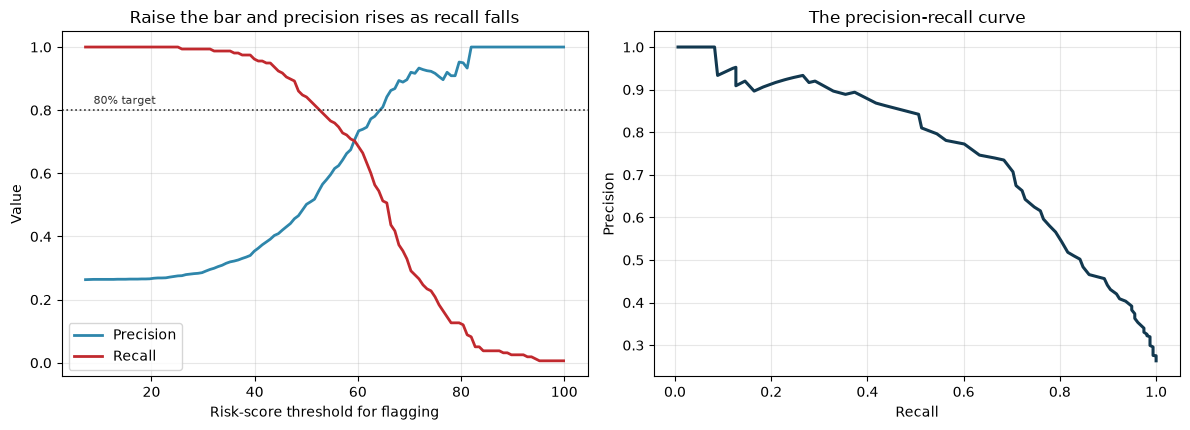

To reach 80% recall you must set the threshold at 52.4,
which flags 234 students and gives precision 54%.
So about 108 of those contacted would have been fine anyway.


In [16]:
# Precision and recall pull against each other. Here is that trade-off, drawn.
rng_pr = np.random.default_rng(11)

n = 600
true_fail = rng_pr.random(n) < 0.25
# A risk score that is informative but not perfect.
score = np.where(true_fail, rng_pr.normal(65, 12, n), rng_pr.normal(45, 12, n))

thresholds = np.linspace(score.min(), score.max(), 120)
precisions, recalls, flagged_counts = [], [], []
for t in thresholds:
    flagged = score >= t
    tp = (flagged & true_fail).sum()
    precisions.append(tp / flagged.sum() if flagged.sum() else np.nan)
    recalls.append(tp / true_fail.sum())
    flagged_counts.append(flagged.sum())

fig, (ax_curve, ax_count) = plt.subplots(1, 2, figsize=(12, 4.4))

ax_curve.plot(thresholds, precisions, linewidth=2, color="#2E86AB", label="Precision")
ax_curve.plot(thresholds, recalls, linewidth=2, color="#C1292E", label="Recall")
ax_curve.axhline(0.80, color="#333", linestyle=":", linewidth=1.2)
ax_curve.text(thresholds[2], 0.82, "80% target", fontsize=8, color="#333")
ax_curve.set_xlabel("Risk-score threshold for flagging")
ax_curve.set_ylabel("Value")
ax_curve.set_title("Raise the bar and precision rises as recall falls")
ax_curve.legend()

ax_count.plot(recalls, precisions, linewidth=2.2, color="#12384f")
ax_count.set_xlabel("Recall")
ax_count.set_ylabel("Precision")
ax_count.set_title("The precision-recall curve")

plt.show()

# What threshold meets the 80% recall target, and what does it cost?
recalls = np.array(recalls)
meets = np.where(recalls >= 0.80)[0]
chosen = meets[-1]
print(f"To reach 80% recall you must set the threshold at {thresholds[chosen]:.1f},")
print(f"which flags {flagged_counts[chosen]} students and gives precision {precisions[chosen]:.0%}.")
print(f"So about {flagged_counts[chosen] - int(recalls[chosen] * true_fail.sum())} of those contacted "
      "would have been fine anyway.")

**How to read it:** the two curves cross. There is no threshold that maximizes both — pushing recall up
always drags precision down, because catching more real cases means casting a wider net.

The right-hand panel is the standard way to show this. Every point on that curve is an achievable
(precision, recall) pair; **you choose one by deciding what a miss costs relative to a false alarm**, and
that is a conversation with the stakeholder, not a calculation.

> ✏️ **Try it:** the instructors said they can contact at most 10 students, not the number printed above.
> Find the threshold that flags exactly 10, and report the recall it achieves. Would you go back to Phase 1
> and renegotiate the 80% target, or the follow-up capacity?

### 2.6 Deployment is not the end — models decay

A deployed model sits in a world that keeps changing, and it does not notice. Two things go wrong:

- **Data drift** — the inputs shift. Next semester's quizzes are harder, so scores fall and the fixed
  threshold of 60 flags far more students.
- **Concept drift** — the relationship itself shifts. The course adds a mandatory tutorial, and quiz average
  stops predicting failure as well as it did.

Neither produces an error message. The model keeps returning confident answers that are increasingly wrong,
which is why "monitor and maintain model quality over time" is written into Phase 6.

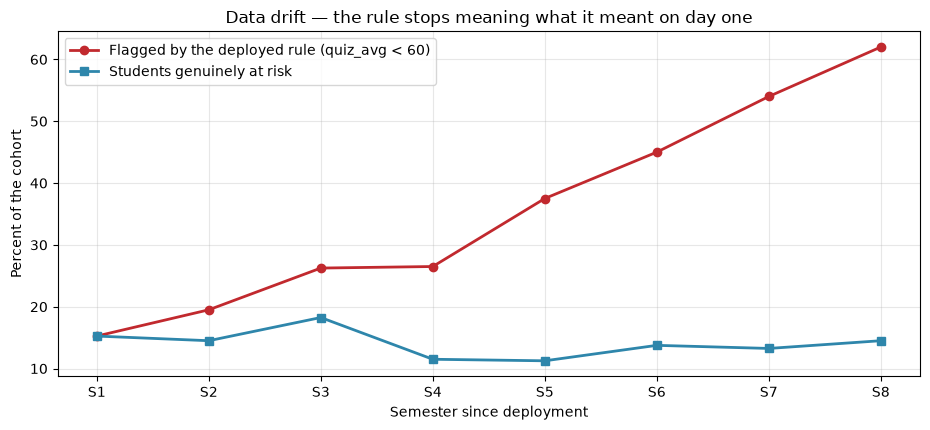

Semester 1: flagged 15%, truly at risk 15%
Semester 8: flagged 62%, truly at risk 14%


In [17]:
rng_drift = np.random.default_rng(23)

semesters = [f"S{i}" for i in range(1, 9)]
# The cohort's mean quiz score slowly falls as the course gets harder.
cohort_means = 72 - np.arange(len(semesters)) * 2.2

flag_rates, true_fail_rates = [], []
for mean in cohort_means:
    scores = rng_drift.normal(mean, 11, 400)
    flag_rates.append((scores < 60).mean())          # the deployed fixed rule
    true_fail_rates.append((scores < mean - 12).mean())  # what "failing" means relative to the cohort

fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.plot(semesters, np.array(flag_rates) * 100, marker="o", linewidth=2,
        color="#C1292E", label="Flagged by the deployed rule (quiz_avg < 60)")
ax.plot(semesters, np.array(true_fail_rates) * 100, marker="s", linewidth=2,
        color="#2E86AB", label="Students genuinely at risk")
ax.set_ylabel("Percent of the cohort")
ax.set_xlabel("Semester since deployment")
ax.set_title("Data drift — the rule stops meaning what it meant on day one")
ax.legend()
plt.show()

print(f"Semester 1: flagged {flag_rates[0]:.0%}, truly at risk {true_fail_rates[0]:.0%}")
print(f"Semester 8: flagged {flag_rates[-1]:.0%}, truly at risk {true_fail_rates[-1]:.0%}")

**How to read it:** the blue line barely moves — the proportion of students genuinely struggling relative to
their cohort is roughly stable. The red line climbs steeply, because the fixed threshold of 60 was calibrated
against a cohort that no longer exists. By the last semester the rule flags a large share of the class, the
instructors stop trusting it, and it quietly falls out of use.

**Nothing broke.** No exception was raised, no test failed. That is what makes drift dangerous, and why the
monitoring in Phase 6 has to watch the *inputs and outputs*, not just whether the code ran.

---
## 3. The nine tasks of data mining

**Data mining** is the process of extracting important or relevant information from raw data. These nine
named tasks are the vocabulary that turns "we have a business problem" into "here is the technique that
solves it."

| Task | Question it answers |
|---|---|
| **Classification** | Which predefined category does this belong to? |
| **Regression** | What number should we predict? |
| **Similarity matching** | How alike are these two things? |
| **Clustering** | Do natural groups exist in this data? |
| **Co-occurrence grouping** | What items are commonly found or purchased together? |
| **Profiling** | What does "normal" behavior look like? |
| **Link prediction** | Should a connection exist between these two items? |
| **Data reduction** | Which fewer dimensions still describe the data well? |
| **Causal modeling** | What actions actually influence this outcome? |

Let's demonstrate each one in code.

### 3.1 Classification — sort into predefined categories

Classification discovers the function that assigns a data item to one of several **pre-defined** classes.
*"How likely is this consumer to respond to our campaign?"*

The output is always one of a fixed, known set of labels. If you find yourself inventing a new label for a
record, you are not doing classification.

performance_class
High      5
Medium    8
Low       7


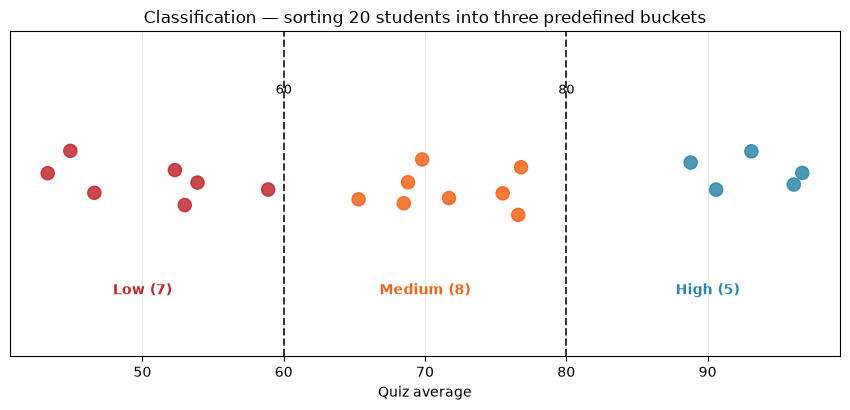

In [18]:
def classify_performance(score):
    if score >= 80:
        return "High"
    elif score >= 60:
        return "Medium"
    return "Low"

students["performance_class"] = students["quiz_avg"].apply(classify_performance)
class_counts = students["performance_class"].value_counts().reindex(["High", "Medium", "Low"])

print(class_counts.to_string())

fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.scatter(students["quiz_avg"], np.zeros(len(students)) + rng_pr.normal(0, 0.03, len(students)),
           c=students["performance_class"].map({"High": "#2E86AB", "Medium": "#F26419", "Low": "#C1292E"}),
           s=90, alpha=0.85)
for boundary in (60, 80):
    ax.axvline(boundary, color="#333", linestyle="--", linewidth=1.4)
    ax.text(boundary, 0.13, f"{boundary}", ha="center", fontsize=9)
ax.text(50, -0.16, f"Low ({class_counts['Low']})", ha="center", color="#C1292E", fontweight="bold")
ax.text(70, -0.16, f"Medium ({class_counts['Medium']})", ha="center", color="#F26419", fontweight="bold")
ax.text(90, -0.16, f"High ({class_counts['High']})", ha="center", color="#2E86AB", fontweight="bold")
ax.set_yticks([])
ax.set_ylim(-0.25, 0.22)
ax.set_xlabel("Quiz average")
ax.set_title("Classification — sorting 20 students into three predefined buckets")
plt.show()

**How to read it:** the two dashed lines are the **decision boundaries**, and everything about a classifier
is contained in where those boundaries sit. Here we placed them by hand from a known rule. A learned
classifier finds them from data — which is exactly what Chapter 10 does.

Notice the boundaries are *sharp*. A student at 79.9 is "Medium" and one at 80.1 is "High," despite being
essentially identical. That discontinuity is inherent to classification, and it is one reason many systems
report a **probability** rather than a hard label.

### 3.2 Regression — predict a number

Regression predicts a **number**, not a category. *"How much will she use the service? How much money is
spent on advertising?"*

The lecture's example: advertising spend driving sales, fitted with a simple linear regression.

In [19]:
# Simulate advertising spend driving sales, then fit a line by least squares.
ad_spend = rng.uniform(5, 50, 15)                       # thousands of baht
sales = 20 + 3.5 * ad_spend + rng.normal(0, 15, 15)     # thousands of baht

slope, intercept = np.polyfit(ad_spend, sales, 1)
print(f"Fitted line: sales = {slope:.2f} * ad_spend + {intercept:.2f}")
print(f"(The true relationship we simulated was: sales = 3.50 * ad_spend + 20.00)")

predicted_at_30 = slope * 30 + intercept
print(f"\nPrediction for 30k baht of ad spend: {predicted_at_30:.1f}k baht in sales")

# How much of the variation in sales does ad spend explain?
fitted = slope * ad_spend + intercept
ss_residual = ((sales - fitted) ** 2).sum()
ss_total = ((sales - sales.mean()) ** 2).sum()
r_squared = 1 - ss_residual / ss_total
print(f"R-squared: {r_squared:.3f}  — ad spend explains {r_squared:.0%} of the variation in sales")

Fitted line: sales = 3.25 * ad_spend + 27.27
(The true relationship we simulated was: sales = 3.50 * ad_spend + 20.00)

Prediction for 30k baht of ad spend: 124.7k baht in sales
R-squared: 0.962  — ad spend explains 96% of the variation in sales


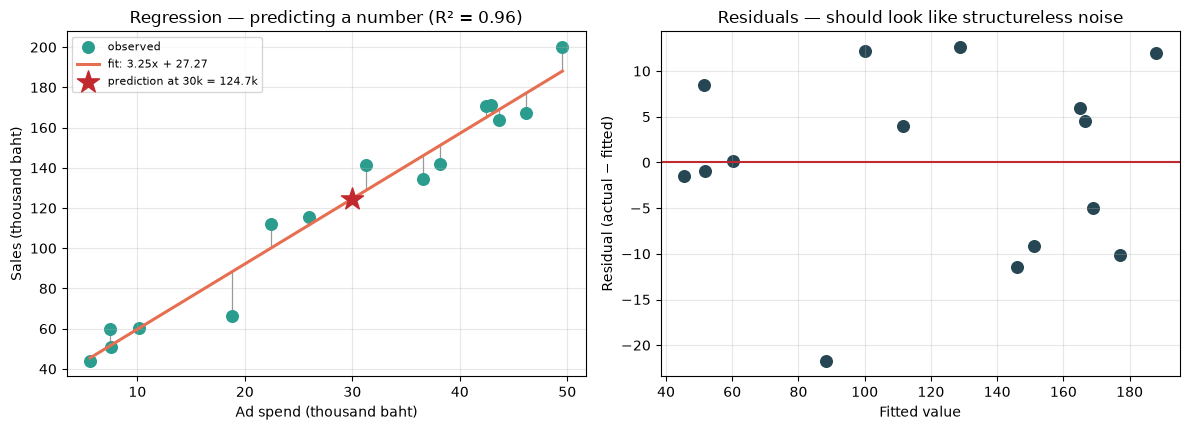

In [20]:
fig, (ax_fit, ax_resid) = plt.subplots(1, 2, figsize=(12, 4.4))

ax_fit.scatter(ad_spend, sales, color="#2A9D8F", s=70, label="observed")
grid = np.linspace(ad_spend.min(), ad_spend.max(), 50)
ax_fit.plot(grid, slope * grid + intercept, color="#E76F51", linewidth=2.2,
            label=f"fit: {slope:.2f}x + {intercept:.2f}")
# Draw the residuals — the errors the fit is minimizing.
for x, y, y_hat in zip(ad_spend, sales, fitted):
    ax_fit.plot([x, x], [y, y_hat], color="#999", linewidth=0.9, zorder=0)
ax_fit.scatter([30], [predicted_at_30], marker="*", s=280, color="#C1292E", zorder=5,
               label=f"prediction at 30k = {predicted_at_30:.1f}k")
ax_fit.set_xlabel("Ad spend (thousand baht)")
ax_fit.set_ylabel("Sales (thousand baht)")
ax_fit.set_title(f"Regression — predicting a number (R² = {r_squared:.2f})")
ax_fit.legend(fontsize=8)

ax_resid.scatter(fitted, sales - fitted, color="#264653", s=70)
ax_resid.axhline(0, color="#C1292E", linewidth=1.5)
ax_resid.set_xlabel("Fitted value")
ax_resid.set_ylabel("Residual (actual − fitted)")
ax_resid.set_title("Residuals — should look like structureless noise")

plt.show()

**How to read it:** the gray vertical segments in the left panel are the **residuals** — the vertical distance
from each point to the line. Least-squares fitting chooses the line that makes the sum of their squares as
small as possible. Nothing more mysterious than that.

The right panel is the check nobody does and everybody should. Residuals should scatter randomly around zero
with no pattern. If they curve, the relationship is not linear; if they fan out, the variability grows with
the prediction, and your uncertainty estimates are wrong. Here they look like noise, which is the answer you
want.

**Classification vs. regression in one line:** classification answers *"which bucket?"*; regression answers
*"what number?"* Predicting a T-shirt as S/M/L is classification; predicting the chest measurement in
centimeters is regression.

### 3.3 Similarity matching — how alike are two things?

Similarity matching recognizes similar individuals based on known information. If two entities are similar in
some way, they often share other characteristics too — which is what makes it useful for recommendation,
deduplication, and "customers like you."

The standard measure for numeric feature vectors is **cosine similarity**:

$$\text{cosine}(a, b) = \frac{a \cdot b}{\|a\| \times \|b\|}$$

It measures the **angle** between two vectors, ignoring their length.

In [21]:
def cosine_similarity(a, b):
    a, b = np.array(a, dtype=float), np.array(b, dtype=float)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

# Three cameras, each described by [price, rating, screen size], all normalized to 0-1.
camera_a = [0.65, 0.90, 0.30]
camera_b = [0.70, 0.86, 0.30]   # very similar to A
camera_c = [0.10, 0.40, 0.95]   # quite different

print(f"Similarity(A, B) = {cosine_similarity(camera_a, camera_b):.3f}   (very similar cameras)")
print(f"Similarity(A, C) = {cosine_similarity(camera_a, camera_c):.3f}   (quite different cameras)")
print(f"Similarity(B, C) = {cosine_similarity(camera_b, camera_c):.3f}")

Similarity(A, B) = 0.998   (very similar cameras)
Similarity(A, C) = 0.596   (quite different cameras)
Similarity(B, C) = 0.588


In [22]:
# Cosine measures ANGLE, not distance. That difference matters, and here is when.
budget_shopper = [0.10, 0.15, 0.05]      # cares a little about everything
premium_shopper = [0.80, 0.95, 0.45]     # same PRIORITIES, much bigger appetite

print("Two shoppers with the same priorities but very different budgets:")
print(f"  Cosine similarity  : {cosine_similarity(budget_shopper, premium_shopper):.3f}  -> nearly identical")
print(f"  Euclidean distance : {np.linalg.norm(np.array(budget_shopper) - np.array(premium_shopper)):.3f}"
      "  -> far apart")

print("\nWhich is right depends on the question:")
print("  'Do they want the same KIND of thing?'  -> cosine (angle)")
print("  'Would the same product suit both?'     -> Euclidean (distance)")

Two shoppers with the same priorities but very different budgets:
  Cosine similarity  : 0.991  -> nearly identical
  Euclidean distance : 1.136  -> far apart

Which is right depends on the question:
  'Do they want the same KIND of thing?'  -> cosine (angle)
  'Would the same product suit both?'     -> Euclidean (distance)


**How to read it:** cosine similarity says these two shoppers are nearly the same, because their preference
*profiles* point in the same direction. Euclidean distance says they are far apart, because one buys ten
times as much. Neither is wrong — they answer different questions.

This is the most common source of confusion in similarity work. **The metric encodes an assumption about
what "similar" means,** and choosing it is a modeling decision, not a default.

⚠️ Both metrics also require that your features are on comparable scales. If price is in baht (thousands) and
rating is 1–5, price will dominate every calculation regardless of importance. That is why all three camera
vectors above are normalized to 0–1 first.

### 3.4 Clustering — do natural groups exist?

*"Do my customers form natural groups?"* Clustering finds structure **without predefined labels** — the key
difference from classification, where the categories are known in advance.

Chapters 9 and 11 cover the algorithms in full depth. Here we build the most famous one, **k-means**, from
scratch in about ten lines, because it is genuinely that simple.

In [23]:
# Simulate two natural customer segments: (monthly spend, visits per month).
low_spenders = rng.normal(loc=(20, 2), scale=(5, 1), size=(15, 2))
high_spenders = rng.normal(loc=(80, 8), scale=(8, 2), size=(15, 2))
customers = np.vstack([low_spenders, high_spenders])

print(f"{len(customers)} customers, described by {customers.shape[1]} features.")
print("The algorithm below is never told which group anyone belongs to.")

30 customers, described by 2 features.
The algorithm below is never told which group anyone belongs to.


In [24]:
def kmeans(points, k, n_iterations=20, seed=0):
    # Lloyd's algorithm: assign each point to its nearest center, then move each center
    # to the mean of the points assigned to it. Repeat until nothing moves.
    generator = np.random.default_rng(seed)

    # Features are on very different scales (spend ~80, visits ~8), so standardize first —
    # otherwise "spend" alone decides every distance.
    mean, std = points.mean(axis=0), points.std(axis=0)
    scaled = (points - mean) / std

    centers = scaled[generator.choice(len(scaled), k, replace=False)]
    history = []
    for _ in range(n_iterations):
        distances = np.linalg.norm(scaled[:, None, :] - centers[None, :, :], axis=2)
        labels = distances.argmin(axis=1)
        history.append((centers * std + mean, labels.copy()))
        new_centers = np.array([scaled[labels == j].mean(axis=0) if (labels == j).any() else centers[j]
                                for j in range(k)])
        if np.allclose(new_centers, centers):
            break
        centers = new_centers
    return centers * std + mean, labels, history

centers, labels, history = kmeans(customers, k=2, seed=888102)

print(f"Converged after {len(history)} iterations.")
for j, center in enumerate(centers):
    members = (labels == j).sum()
    print(f"  Cluster {j}: {members} customers, center at "
          f"spend={center[0]:.1f}, visits={center[1]:.1f}")

Converged after 3 iterations.
  Cluster 0: 15 customers, center at spend=18.8, visits=1.9
  Cluster 1: 15 customers, center at spend=79.1, visits=8.6


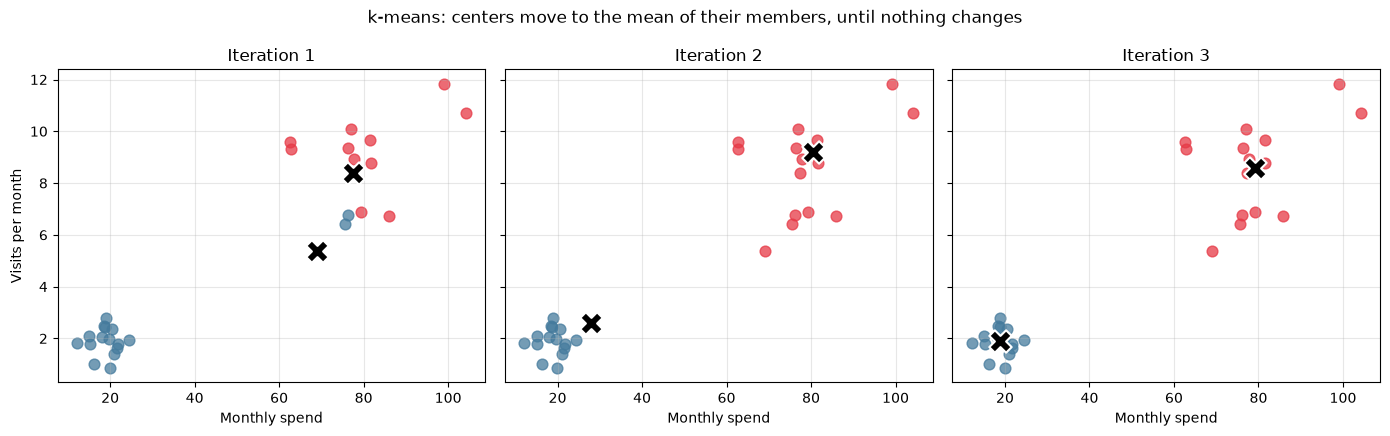

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharex=True, sharey=True)
snapshots = [0, min(1, len(history) - 1), len(history) - 1]
palette = ["#457B9D", "#E63946"]

for ax, step in zip(axes, snapshots):
    step_centers, step_labels = history[step]
    for j in range(2):
        mask = step_labels == j
        ax.scatter(customers[mask, 0], customers[mask, 1], color=palette[j], alpha=0.75, s=60)
    ax.scatter(step_centers[:, 0], step_centers[:, 1], marker="X", s=260,
               color="black", edgecolor="white", linewidth=1.5, zorder=5)
    ax.set_xlabel("Monthly spend")
    ax.set_title(f"Iteration {step + 1}")
axes[0].set_ylabel("Visits per month")
fig.suptitle("k-means: centers move to the mean of their members, until nothing changes")
plt.show()

**How to read it:** the black crosses are the cluster centers. They start at randomly chosen data points and
walk to the middle of whatever they attracted, dragging the assignment with them. Within two or three
iterations they settle on the two obvious blobs.

We never told the algorithm what "budget" or "premium" meant — those names are ours, applied afterwards.
**That labeling step is where clustering becomes useful and also where it becomes dangerous:** the algorithm
will happily produce k groups whether or not k groups exist, and it is on you to check whether the groups
mean anything.

Two practical notes the code makes visible:

- **Standardization matters.** Spend runs to 80 and visits to 8. Without scaling, distance is essentially
  "difference in spend" and the visits column is ignored.
- **k is your choice.** Ask for 5 clusters and you will get 5. Chapter 11 covers how to choose it honestly.

> ✏️ **Try it:** call `kmeans(customers, k=4)` and plot the result. Do the four groups mean anything, or has
> the algorithm just split two real groups in half?

### 3.5 Co-occurrence grouping — what is bought together?

*"What items are commonly found or purchased together?"* Also called **market basket analysis**, frequent
itemset mining, or association rule discovery. This is the formal data-mining name for the receipt pipeline
built in Chapter 2.

In [26]:
rng_basket = np.random.default_rng(31)

# Simulate 800 supermarket baskets with one genuine association planted in them.
baskets = []
for _ in range(800):
    basket = set()
    if rng_basket.random() < 0.55:
        basket.add("rice")
    buys_noodles = rng_basket.random() < 0.35
    if buys_noodles:
        basket.add("instant noodles")
        if rng_basket.random() < 0.60:
            basket.add("egg")               # noodle buyers usually add eggs
    elif rng_basket.random() < 0.15:
        basket.add("egg")
    if rng_basket.random() < 0.30:
        basket.add("milk")
    baskets.append(basket)

def rule_metrics(antecedent, consequent, all_baskets):
    n = len(all_baskets)
    n_a = sum(1 for b in all_baskets if antecedent in b)
    n_b = sum(1 for b in all_baskets if consequent in b)
    n_ab = sum(1 for b in all_baskets if antecedent in b and consequent in b)
    support = n_ab / n
    confidence = n_ab / n_a if n_a else np.nan
    lift = confidence / (n_b / n) if n_b else np.nan
    return {"rule": f"{antecedent} -> {consequent}",
            "support": round(support, 3), "confidence": round(confidence, 3), "lift": round(lift, 2)}

items = ["rice", "instant noodles", "egg", "milk"]
rules = pd.DataFrame([rule_metrics(a, b, baskets) for a in items for b in items if a != b])
rules.sort_values("lift", ascending=False).reset_index(drop=True)

,rule,support,confidence,lift
0,egg -> instant noodles,0.206,0.688,1.98
1,instant noodles -> egg,0.206,0.594,1.98
2,milk -> instant noodles,0.099,0.356,1.02
3,instant noodles -> milk,0.099,0.284,1.02
4,egg -> rice,0.156,0.521,0.98
5,milk -> rice,0.145,0.523,0.98
6,rice -> milk,0.145,0.273,0.98
7,rice -> egg,0.156,0.294,0.98
8,instant noodles -> rice,0.177,0.511,0.96
9,rice -> instant noodles,0.177,0.334,0.96


**How to read it:** sort by **lift**, not confidence. `instant noodles -> egg` sits at the top with lift well
above 1 — the association we planted. Rules involving `rice` have respectable confidence (rice is in over half
of all baskets) and lift near 1, meaning they tell you nothing you did not already know from the popularity
of rice.

Chapter 2 explains these three measures in full. The one-line version: **support** = how often, **confidence**
= how reliably, **lift** = whether it beats chance.

### 3.6 Profiling — what does "normal" look like?

Profiling builds a description of typical behavior, then flags anything unusual against it. It is the standard
backbone of fraud detection, and its defining feature is that **the profile is learned from data**, not
written down by a person.

In [27]:
# Learn a profile from 200 genuine transactions.
normal_transactions = rng.normal(500, 120, 200)          # baht
profile_mean, profile_std = normal_transactions.mean(), normal_transactions.std()
print(f"Profile of 'normal' spending: mean = {profile_mean:.0f} baht, std = {profile_std:.0f} baht")

# Check a new batch, including two deliberate outliers.
new_transactions = np.append(rng.normal(500, 120, 8), [4200, 15])
z_scores = (new_transactions - profile_mean) / profile_std
flagged = np.abs(z_scores) > 3          # more than 3 standard deviations from the profile

print("\nNew transactions checked against the profile:")
for amount, z, is_flagged in zip(new_transactions, z_scores, flagged):
    marker = "   <- FLAGGED" if is_flagged else ""
    print(f"  {amount:8.0f} baht   (z = {z:+6.2f}){marker}")

Profile of 'normal' spending: mean = 496 baht, std = 112 baht

New transactions checked against the profile:
       603 baht   (z =  +0.95)
       356 baht   (z =  -1.25)
       582 baht   (z =  +0.77)
       384 baht   (z =  -1.00)
       507 baht   (z =  +0.10)
       573 baht   (z =  +0.69)
       480 baht   (z =  -0.14)
       426 baht   (z =  -0.63)
      4200 baht   (z = +33.10)   <- FLAGGED
        15 baht   (z =  -4.30)   <- FLAGGED


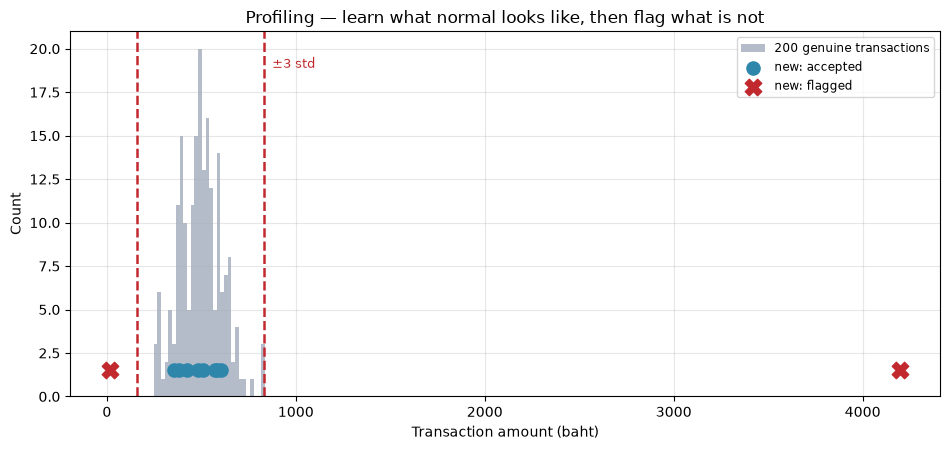

In [28]:
fig, ax = plt.subplots(figsize=(9.6, 4.6))
ax.hist(normal_transactions, bins=30, color="#8D99AE", alpha=0.65, label="200 genuine transactions")
for boundary, sign in [(profile_mean + 3 * profile_std, "+"), (profile_mean - 3 * profile_std, "-")]:
    ax.axvline(boundary, color="#C1292E", linestyle="--", linewidth=1.8)
ax.text(profile_mean + 3 * profile_std, ax.get_ylim()[1] * 0.9, "  ±3 std", color="#C1292E", fontsize=9)
ax.scatter(new_transactions[~flagged], np.full((~flagged).sum(), 1.5), s=90,
           color="#2E86AB", zorder=5, label="new: accepted")
ax.scatter(new_transactions[flagged], np.full(flagged.sum(), 1.5), s=140, marker="X",
           color="#C1292E", zorder=5, label="new: flagged")
ax.set_xlabel("Transaction amount (baht)")
ax.set_ylabel("Count")
ax.set_title("Profiling — learn what normal looks like, then flag what is not")
ax.legend(fontsize=8.5)
plt.show()

**How to read it:** the histogram *is* the profile. The dashed lines are three standard deviations either
side, and the two crosses are the transactions that fell outside. A 4,200-baht purchase is more than 30
standard deviations out — not a borderline call.

Two cautions that matter in production:

- **The 3-sigma rule assumes a roughly bell-shaped distribution.** Real spending is right-skewed (a few large
  purchases, many small ones), so a naive 3-sigma rule flags legitimate large purchases constantly. Robust
  alternatives use the median and interquartile range instead.
- **Even at 3 sigma, about 0.3% of genuine transactions get flagged.** On a million transactions a day, that
  is 3,000 false alarms. The threshold is a business decision about how much customer annoyance a blocked card
  is worth.

In [29]:
# The false-alarm arithmetic, which decides whether a fraud rule is usable at all.
daily_transactions = 1_000_000
true_fraud_rate = 0.001

for sigma in (2, 3, 4):
    # Fraction of genuine transactions beyond +/- sigma, for a normal distribution.
    from math import erfc, sqrt
    false_alarm_rate = erfc(sigma / sqrt(2))
    false_alarms = daily_transactions * (1 - true_fraud_rate) * false_alarm_rate
    print(f"{sigma}-sigma threshold: {false_alarm_rate:.4%} of genuine transactions flagged "
          f"-> {false_alarms:,.0f} false alarms per day")

2-sigma threshold: 4.5500% of genuine transactions flagged -> 45,455 false alarms per day
3-sigma threshold: 0.2700% of genuine transactions flagged -> 2,697 false alarms per day
4-sigma threshold: 0.0063% of genuine transactions flagged -> 63 false alarms per day


**How to read it:** at 2 sigma the rule generates tens of thousands of false alarms a day and is unusable. At
4 sigma it generates a manageable number and misses more real fraud. **This trade-off is the same
precision-recall tension from Section 2.5**, reappearing in a completely different task — which is exactly why
it is worth learning once, properly.

### 3.7 Link prediction — will a connection form?

*"Since Paul and Karen share 3 friends, maybe you'd like to be Karen's friend?"* Link prediction estimates
whether a connection **should** exist between two nodes in a network — predicting connections rather than
merely describing existing ones.

The same idea powers movie recommendations, modeled as a graph between customers and the movies they have
watched or rated.

Paul and Karen share 2 common friends: ['A', 'B']
They are not directly connected — so the system might suggest they connect.


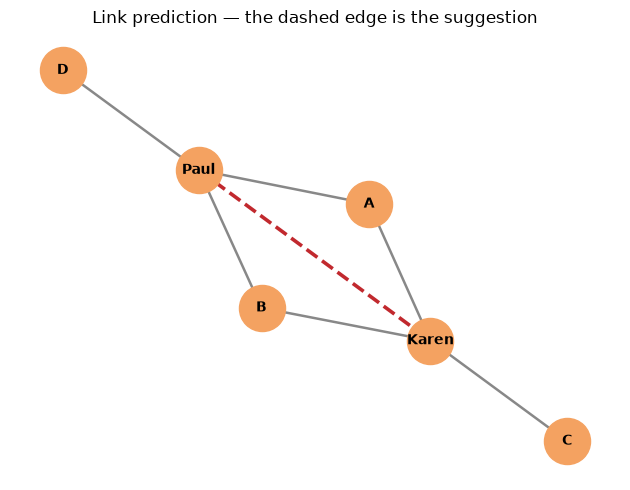

In [30]:
# A tiny friendship network.
G = nx.Graph()
G.add_edges_from([("Paul", "A"), ("Paul", "B"), ("Karen", "A"),
                  ("Karen", "B"), ("Karen", "C"), ("Paul", "D")])

common = list(nx.common_neighbors(G, "Paul", "Karen"))
print(f"Paul and Karen share {len(common)} common friends: {common}")
print("They are not directly connected — so the system might suggest they connect.")

fig, ax = plt.subplots(figsize=(6.4, 5))
pos = nx.spring_layout(G, seed=888102)
nx.draw_networkx_edges(G, pos, ax=ax, width=1.8, edge_color="#888")
nx.draw_networkx_edges(G, pos, ax=ax, edgelist=[("Paul", "Karen")], width=2.6,
                       edge_color="#C1292E", style="dashed")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#F4A261", node_size=1100)
nx.draw_networkx_labels(G, pos, ax=ax, font_weight="bold", font_size=10)
ax.set_title("Link prediction — the dashed edge is the suggestion")
ax.axis("off")
ax.grid(False)
plt.show()

In [31]:
# Score EVERY pair that is not yet connected, so the suggestions can be ranked.
candidates = []
for u, v in nx.non_edges(G):
    shared = list(nx.common_neighbors(G, u, v))
    neighbors_u, neighbors_v = set(G[u]), set(G[v])
    union = neighbors_u | neighbors_v
    jaccard = len(shared) / len(union) if union else 0.0
    candidates.append({"pair": f"{u} - {v}", "common neighbors": len(shared),
                       "shared": ", ".join(shared) or "-", "jaccard": round(jaccard, 3)})

suggestions = (pd.DataFrame(candidates)
               .sort_values(["common neighbors", "jaccard"], ascending=False)
               .reset_index(drop=True))
suggestions

,pair,common neighbors,shared,jaccard
0,A - B,2,"Karen, Paul",1.0
1,Paul - Karen,2,"A, B",0.5
2,D - A,1,Paul,0.5
3,D - B,1,Paul,0.5
4,C - A,1,Karen,0.5
5,C - B,1,Karen,0.5
6,Paul - C,0,-,0.0
7,D - Karen,0,-,0.0
8,D - C,0,-,0.0


**How to read it:** ranking is the point. A real social network has millions of non-edges, so "they share a
friend" is far too weak a filter — you need a **score** to sort by.

The two scores shown behave differently:

- **Common neighbors** simply counts shared friends. It favors popular nodes, because someone with 500
  friends shares friends with almost everyone.
- **Jaccard** divides by the size of the combined friend circle, so it asks *what fraction* of their combined
  circle is shared. Two people with five friends each, four in common, score far higher than a celebrity who
  happens to overlap with you by four.

Paul and Karen top the list on both, which is why the suggestion is a good one.

### 3.8 Data reduction — fewer, more useful dimensions

*"Which latent dimensions describe consumer taste preferences?"* Redundant columns can often be safely
combined, leaving fewer dimensions that still describe the data well.

In [32]:
# Two of these three columns are almost perfectly redundant.
ratings = pd.DataFrame({"screen_quality": rng.uniform(1, 10, 10).round(1)})
ratings["display_quality"] = ratings["screen_quality"] + rng.normal(0, 0.3, 10)
ratings["battery_life"] = rng.uniform(1, 10, 10).round(1)

correlation_matrix = ratings.corr().round(2)
print(correlation_matrix.to_string())

ratings["screen_score"] = ratings[["screen_quality", "display_quality"]].mean(axis=1)
reduced = ratings[["screen_score", "battery_life"]]
print(f"\nReduced from 3 original columns to {reduced.shape[1]} columns by averaging the redundant pair.")

                 screen_quality  display_quality  battery_life
screen_quality             1.00             0.99         -0.21
display_quality            0.99             1.00         -0.13
battery_life              -0.21            -0.13          1.00

Reduced from 3 original columns to 2 columns by averaging the redundant pair.


**How to read it:** `screen_quality` and `display_quality` correlate at 0.99 — they carry almost the same
information twice. Averaging them into one `screen_score` cuts a dimension while losing almost nothing.

That works when you can *see* the redundancy in a 3×3 matrix. With 200 columns you cannot, which is what
**principal component analysis (PCA)** automates: it finds the directions along which the data actually
varies, and lets you keep the few that matter.

In [33]:
# PCA from scratch, using the singular value decomposition.
X = ratings[["screen_quality", "display_quality", "battery_life"]].to_numpy()
X_centered = X - X.mean(axis=0)

U, singular_values, Vt = np.linalg.svd(X_centered, full_matrices=False)
variance_explained = singular_values ** 2 / (singular_values ** 2).sum()

print("Variance explained by each principal component:")
for i, share in enumerate(variance_explained, start=1):
    print(f"  PC{i}: {share:.1%}   (cumulative {variance_explained[:i].sum():.1%})")

print("\nWhat each component is made of (loadings):")
loadings = pd.DataFrame(Vt.T, index=["screen_quality", "display_quality", "battery_life"],
                        columns=[f"PC{i+1}" for i in range(3)]).round(2)
print(loadings.to_string())

Variance explained by each principal component:
  PC1: 73.6%   (cumulative 73.6%)
  PC2: 26.0%   (cumulative 99.6%)
  PC3: 0.4%   (cumulative 100.0%)

What each component is made of (loadings):
                  PC1   PC2   PC3
screen_quality  -0.69  0.06 -0.73
display_quality -0.71  0.16  0.68
battery_life     0.16  0.98 -0.07


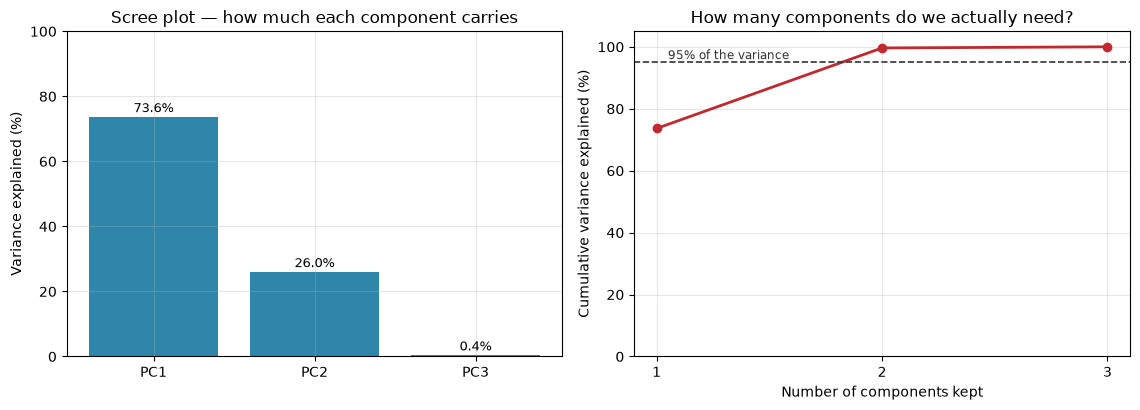

In [34]:
fig, (ax_scree, ax_cum) = plt.subplots(1, 2, figsize=(11.5, 4.2))

components = [f"PC{i+1}" for i in range(len(variance_explained))]
ax_scree.bar(components, variance_explained * 100, color="#2E86AB")
for comp, share in zip(components, variance_explained):
    ax_scree.text(comp, share * 100 + 1.5, f"{share:.1%}", ha="center", fontsize=9)
ax_scree.set_ylabel("Variance explained (%)")
ax_scree.set_title("Scree plot — how much each component carries")
ax_scree.set_ylim(0, 100)

cumulative = np.cumsum(variance_explained) * 100
ax_cum.plot(range(1, len(cumulative) + 1), cumulative, marker="o", linewidth=2, color="#C1292E")
ax_cum.axhline(95, color="#333", linestyle="--", linewidth=1.2)
ax_cum.text(1.05, 96, "95% of the variance", fontsize=8.5, color="#333")
ax_cum.set_xticks(range(1, len(cumulative) + 1))
ax_cum.set_xlabel("Number of components kept")
ax_cum.set_ylabel("Cumulative variance explained (%)")
ax_cum.set_title("How many components do we actually need?")
ax_cum.set_ylim(0, 105)

plt.show()

**How to read it:** the scree plot shows almost all the variance concentrated in the first two components,
with the third carrying nearly nothing — which is the mathematical statement of "one of these three columns is
redundant." The cumulative plot answers the practical question: keeping two of three components retains well
over 95% of the information, so the third can be dropped.

Read the loadings table alongside it. The component that dominates loads heavily on both screen columns and
lightly on battery, confirming that it *is* essentially the "screen" dimension the manual averaging found —
except PCA discovered it without being told which columns were related.

⚠️ **The cost of PCA is interpretability.** `screen_score` means something to a product manager. "PC1" does
not, and explaining a model built on principal components to a stakeholder is genuinely hard.

### 3.9 Causal modeling — what actually influences what?

*"What causes sales? Why are my customers leaving?"* Causal modeling seeks real cause-and-effect
relationships, not just correlations. This is the ice-cream-and-sunburn distinction from Chapter 3, applied to
business questions.

It is the hardest of the nine tasks, because the answer usually cannot be extracted from observational data at
all. The demonstration below shows why — and what fixes it.

In [35]:
rng_causal = np.random.default_rng(43)

n = 4_000
# Loyal customers are BOTH more likely to install the app AND bigger spenders anyway.
loyalty = rng_causal.normal(0, 1, n)
installed_app = rng_causal.random(n) < (0.2 + 0.5 * (loyalty > 0))

TRUE_APP_EFFECT = 120        # the app genuinely adds 120 baht per month
spend = (800 + 400 * loyalty + TRUE_APP_EFFECT * installed_app
         + rng_causal.normal(0, 150, n))

observational_gap = spend[installed_app].mean() - spend[~installed_app].mean()

print(f"True causal effect of the app      : {TRUE_APP_EFFECT:>6.0f} baht")
print(f"Observed gap (app users vs others) : {observational_gap:>6.0f} baht")
print(f"Overstated by                      : {observational_gap - TRUE_APP_EFFECT:>6.0f} baht "
      f"({observational_gap / TRUE_APP_EFFECT:.1f}x too large)")

True causal effect of the app      :    120 baht
Observed gap (app users vs others) :    433 baht
Overstated by                      :    313 baht (3.6x too large)


In [36]:
# A randomized experiment: assign the app by coin flip, so loyalty cannot influence who gets it.
assigned_app = rng_causal.random(n) < 0.5
spend_experiment = (800 + 400 * loyalty + TRUE_APP_EFFECT * assigned_app
                    + rng_causal.normal(0, 150, n))

experimental_gap = spend_experiment[assigned_app].mean() - spend_experiment[~assigned_app].mean()

print(f"True causal effect          : {TRUE_APP_EFFECT:>6.0f} baht")
print(f"Randomized experiment says  : {experimental_gap:>6.0f} baht   <- recovers the truth")

# Why it works: randomization balances the confounder across the two groups.
print(f"\nMean loyalty, observational groups : "
      f"app {loyalty[installed_app].mean():+.2f} vs no-app {loyalty[~installed_app].mean():+.2f}  (unbalanced)")
print(f"Mean loyalty, randomized groups    : "
      f"app {loyalty[assigned_app].mean():+.2f} vs no-app {loyalty[~assigned_app].mean():+.2f}  (balanced)")

True causal effect          :    120 baht
Randomized experiment says  :    121 baht   <- recovers the truth

Mean loyalty, observational groups : app +0.44 vs no-app -0.37  (unbalanced)
Mean loyalty, randomized groups    : app -0.00 vs no-app -0.01  (balanced)


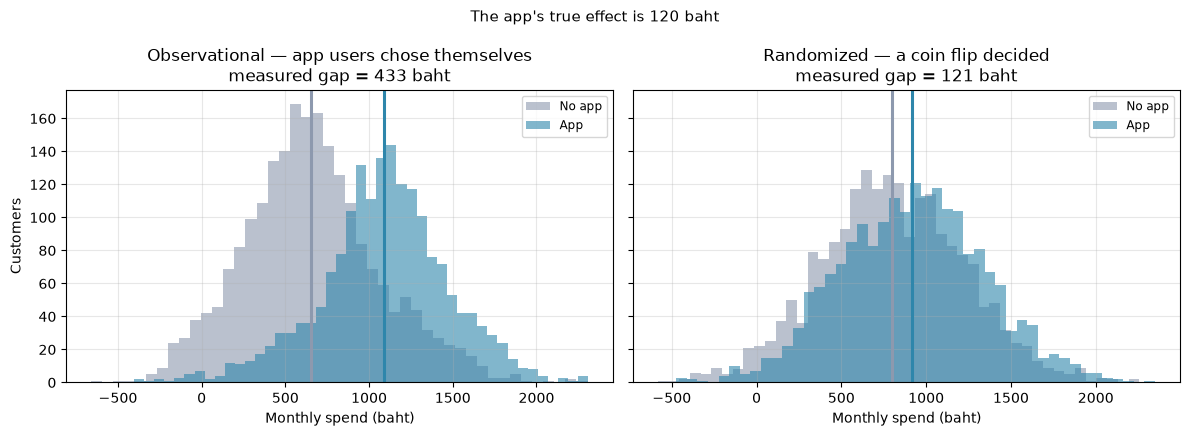

In [37]:
fig, (ax_obs, ax_exp) = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)

for ax, group, gap, title in [
    (ax_obs, installed_app, observational_gap, "Observational — app users chose themselves"),
    (ax_exp, assigned_app, experimental_gap, "Randomized — a coin flip decided"),
]:
    values = spend if ax is ax_obs else spend_experiment
    ax.hist(values[~group], bins=45, alpha=0.6, color="#8D99AE", label="No app")
    ax.hist(values[group], bins=45, alpha=0.6, color="#2E86AB", label="App")
    ax.axvline(values[~group].mean(), color="#8D99AE", linewidth=2.2)
    ax.axvline(values[group].mean(), color="#2E86AB", linewidth=2.2)
    ax.set_xlabel("Monthly spend (baht)")
    ax.set_title(f"{title}\nmeasured gap = {gap:,.0f} baht")
    ax.legend(fontsize=8.5)
ax_obs.set_ylabel("Customers")
fig.suptitle(f"The app's true effect is {TRUE_APP_EFFECT} baht", fontsize=11)
plt.show()

**How to read it:** in the left panel the two distributions are far apart, and a naive analysis would report
that the app more than triples its true effect. Nothing was measured incorrectly — the gap is real. It is
simply **not caused by the app**: loyal customers both installed it and spent more anyway.

In the right panel the app was assigned by a coin flip, so loyalty is balanced between the two groups by
construction, and the measured gap lands on the truth.

This is why the randomized experiment (the A/B test) is the gold standard, and why "we ran the numbers on our
existing customers" is not an answer to a causal question. The last line of the second cell shows the
mechanism explicitly: **randomization balances the confounder, including confounders you never thought to
measure.**

> ✏️ **Try it:** change `0.5 * (loyalty > 0)` to `0.0`, so app installation no longer depends on loyalty at
> all, and re-run. Does the observational estimate now match the truth? What does that tell you about *when*
> observational data is sufficient?

---
## 4. Choosing the right task

Given a business question, which of the nine tasks applies? Two questions get you most of the way there:

1. **Is there a known right answer to learn from?** If yes, the task is *supervised*; if no, *unsupervised*.
2. **What shape is the output?** A category, a number, a group, a score, a ranking, or an effect.

| Your question sounds like… | Task | Supervised? |
|---|---|---|
| "Which category is this?" | Classification | Yes |
| "How much / how many?" | Regression | Yes |
| "Who or what resembles this?" | Similarity matching | No |
| "Are there natural groups here?" | Clustering | No |
| "What goes together?" | Co-occurrence grouping | No |
| "Is this unusual?" | Profiling | No (usually) |
| "Who should connect to whom?" | Link prediction | Partly |
| "Can I describe this with fewer columns?" | Data reduction | No |
| "Would doing X change Y?" | Causal modeling | Needs an experiment |

In [38]:
questions = pd.DataFrame([
    ("Will this customer cancel their subscription next month?", "Classification"),
    ("How many units will we sell in December?", "Regression"),
    ("Which of our 40,000 products is most like this one?", "Similarity matching"),
    ("Do our customers fall into distinct segments?", "Clustering"),
    ("Which products should sit next to each other on the shelf?", "Co-occurrence grouping"),
    ("Is this login attempt suspicious?", "Profiling"),
    ("Which two researchers should we introduce?", "Link prediction"),
    ("Can we summarize 80 survey questions with 5 scores?", "Data reduction"),
    ("Did the new checkout page increase conversions?", "Causal modeling"),
    ("How likely is this loan to default?", "Classification"),
    ("What will this apartment sell for?", "Regression"),
], columns=["Business question", "Task"])

print(questions["Task"].value_counts().to_string())
questions

Task
Classification            2
Regression                2
Similarity matching       1
Clustering                1
Co-occurrence grouping    1
Profiling                 1
Link prediction           1
Data reduction            1
Causal modeling           1


,Business question,Task
0,Will this customer cancel their subscription n...,Classification
1,How many units will we sell in December?,Regression
2,"Which of our 40,000 products is most like this...",Similarity matching
3,Do our customers fall into distinct segments?,Clustering
4,Which products should sit next to each other o...,Co-occurrence grouping
5,Is this login attempt suspicious?,Profiling
6,Which two researchers should we introduce?,Link prediction
7,Can we summarize 80 survey questions with 5 sc...,Data reduction
8,Did the new checkout page increase conversions?,Causal modeling
9,How likely is this loan to default?,Classification


**How to read it:** two questions here are worth arguing about, and the argument is the useful part.

"Will this customer cancel next month?" is classification if you want a yes/no flag, and regression if you
want a *probability*. Most production churn systems predict the probability and then apply a threshold — which
is both tasks, stacked.

"Did the new checkout page increase conversions?" looks like a comparison of two numbers and is in fact a
causal question. If the new page was shown to everyone at once, no amount of analysis will separate its effect
from whatever else changed that week. Section 3.9 explains why.

---
## 5. The same nine tasks, across every industry

| Industry | Example applications | Dominant data mining task |
|---|---|---|
| **Retail / Consumer** | Market basket analysis, campaign management, supply-chain analytics | Co-occurrence grouping |
| **Finance & Fraud** | Risk analysis, fraud detection, credit scoring, trade surveillance | Profiling / classification |
| **Web & Digital Media** | Clickstream analytics, ad targeting, social graph analysis | Clustering |
| **Health & Life Sciences** | Clinical trials, disease pattern analysis, drug discovery | Regression / causal modeling |
| **Telecommunications** | Churn prevention, network optimization, call detail record analysis | Classification (churn) |
| **Ecommerce** | Recommendation engines, event analytics, next-best-offer | Similarity matching |

In [39]:
applications = pd.DataFrame({
    "Industry": ["Retail / Consumer", "Finance & Fraud", "Web & Digital Media",
                 "Health & Life Sciences", "Telecommunications", "Ecommerce"],
    "Example data mining task": ["Co-occurrence grouping", "Profiling / classification", "Clustering",
                                 "Regression / causal modeling", "Classification (churn)",
                                 "Similarity matching"],
    "The same technique as…": ["Chapter 2's receipts", "Section 3.6 above", "Section 3.4 above",
                               "Section 3.9 above", "Section 2.1's at-risk students",
                               "Chapter 1's recommender"],
})
applications

,Industry,Example data mining task,The same technique as…
0,Retail / Consumer,Co-occurrence grouping,Chapter 2's receipts
1,Finance & Fraud,Profiling / classification,Section 3.6 above
2,Web & Digital Media,Clustering,Section 3.4 above
3,Health & Life Sciences,Regression / causal modeling,Section 3.9 above
4,Telecommunications,Classification (churn),Section 2.1's at-risk students
5,Ecommerce,Similarity matching,Chapter 1's recommender


**How to read it:** the last column is the point of the whole chapter. Telecom churn prediction and flagging
at-risk students are *the same task* with different words on it — a supervised binary classification with an
expensive false negative and a limited follow-up budget. Retail's market basket analysis is Chapter 2's
grocery receipts at scale.

**The technique is general-purpose; the industry supplies the data and the question.** That is why a data
scientist can move between sectors, and why the nine tasks are worth memorizing as a vocabulary rather than
as nine unrelated recipes.

---
## 6. Glossary

| Term | Meaning |
|---|---|
| **Business problem** | A situation that cannot be ignored: an issue, a threat, or an opportunity |
| **Problem statement** | Current state + objective + measurable success criteria |
| **SMART** | Specific, Measurable, Achievable, Relevant, Time-bound |
| **KPI** | Key performance indicator — the number the business is judged on |
| **CRISP-DM** | CRoss Industry Standard Process for Data Mining; six cyclical phases |
| **Feature engineering** | Creating new input columns from existing ones |
| **Baseline** | The simplest model, which anything fancier must beat |
| **Confusion matrix** | The 2×2 table of true/false positives and negatives |
| **Recall** | Of the real cases, the fraction the model caught |
| **Precision** | Of the flagged cases, the fraction that were real |
| **Class imbalance** | One class is rare, making accuracy a misleading metric |
| **Data drift / concept drift** | Inputs shift / the input-output relationship shifts, after deployment |
| **Data mining** | Extracting relevant patterns from raw data |
| **Classification / regression** | Predict a category / predict a number |
| **Similarity matching** | Score how alike two entities are (e.g. cosine similarity) |
| **Clustering** | Find natural groups without predefined labels |
| **k-means** | The standard clustering algorithm: assign to nearest center, move centers, repeat |
| **Co-occurrence grouping** | Market basket analysis: what is bought together |
| **Profiling** | Learn what "normal" looks like, then flag departures |
| **Link prediction** | Score whether an edge should exist between two nodes |
| **Data reduction / PCA** | Fewer dimensions that still describe the data well |
| **Causal modeling** | Establish what actually influences an outcome |
| **A/B test** | A randomized experiment; the reliable way to answer a causal question |
| **Confounder** | A variable that influences both the supposed cause and the effect |

---
## 7. Check your understanding

**Q1.** "Our competitor just opened three branches near ours." Issue, threat, or opportunity?

<details><summary>Answer</summary>

A threat — it originates outside the organization and could go wrong. If your response is "and their
customers now have to pass our store," you have reframed it as an opportunity, which is a legitimate and
often more productive framing.
</details>

**Q2.** What is wrong with the success criterion "achieve 95% model accuracy"?

<details><summary>Answer</summary>

It is not *relevant* — it measures the model, not the business. And on an imbalanced problem it can be met by
a model that predicts one constant, as Section 2.5 showed with 97.5% accuracy from predicting "nobody fails."
</details>

**Q3.** In CRISP-DM, evaluation shows the model does not meet the business criteria. Where do you go next?

<details><summary>Answer</summary>

Back — usually to data preparation, to engineer better features, sometimes to business understanding, if the
target itself was wrong. Not to deployment. The loop-back is the whole point of the cycle.
</details>

**Q4.** Roughly what proportion of a data science project is spent on modeling?

<details><summary>Answer</summary>

Around 10–15%. Data understanding plus data preparation take about 60%. The exact figures vary; the ordering
does not.
</details>

**Q5.** A hospital wants to flag patients at risk of readmission. Missing one is dangerous; following up costs
a nurse an hour. Which metric should the success criteria use?

<details><summary>Answer</summary>

Both, with recall leading. Recall is primary because a missed case is dangerous, but a recall-only target is
met by flagging everyone, which the nurse's hour makes impossible. State a recall floor *and* a cap on how
many patients can be flagged — exactly the shape of the constraint in Section 2.1.
</details>

**Q6.** "Do our customers form distinct segments?" versus "Is this customer in the premium segment?" Which
tasks are these?

<details><summary>Answer</summary>

The first is clustering (unsupervised — the groups are not known in advance). The second is classification
(supervised — the categories already exist and you are sorting into them). Note that the second only becomes
possible *after* the first has defined what "premium" means.
</details>

**Q7.** Two customers have preference vectors [0.1, 0.2, 0.1] and [0.5, 1.0, 0.5]. Are they similar?

<details><summary>Answer</summary>

By cosine similarity, essentially identical — the second is exactly 5× the first, so the vectors point the
same way. By Euclidean distance, far apart. They want the same kind of thing in very different quantities, and
which answer you need depends on whether you are recommending a product category or a specific price point.
</details>

**Q8.** An analysis finds that customers who use the loyalty app spend 3× more. Should you promote the app?

<details><summary>Answer</summary>

Not on this evidence. Section 3.9 showed exactly this pattern arising when loyal customers both install the
app and spend more anyway — the observational gap overstated the true effect several times over. Run an
experiment: offer the app to a random subset and compare.
</details>

**Q9.** Your fraud rule flags transactions more than 3 standard deviations from a customer's profile. It
worked well at launch and now generates constant false alarms. What happened?

<details><summary>Answer</summary>

Drift. Either the customer's spending pattern changed (data drift) or the profile was learned during an
unusual period. The profile needs periodic relearning, and Phase 6 monitoring should have caught the rise in
flag rate before the customers did.
</details>

**Q10.** You reduce 80 survey questions to 5 principal components and build an accurate model on them. The
marketing director asks what drives the prediction. What is the difficulty?

<details><summary>Answer</summary>

Principal components are mathematical combinations of all 80 questions, not meaningful concepts, so "PC2
increased" is not an explanation anyone can act on. You can inspect the loadings to see which questions
dominate each component and name them, but this is interpretation, not a guarantee — and it is the standard
price of data reduction.
</details>

---
## 8. Summary — key takeaways

1. **A business problem is an issue, a threat, or an opportunity**, and it must be dealt with systematically
   rather than reacted to.
2. **Problem statements need three parts**: current state, objective, and *measurable* success criteria. The
   third is the one people skip, and skipping it makes success unfalsifiable.
3. **Success criteria must be relevant to the business**, not to the model. "95% accuracy" is a technical
   score that can be achieved by a model that has learned nothing.
4. **CRISP-DM is repeatable**: business understanding → data understanding → data preparation → modeling →
   evaluation → deployment. It is a cycle, and the loop-backs are where the real work happens.
5. **Data preparation dominates.** Roughly 60% of effort goes into understanding and preparing data; modeling
   is about 12%.
6. **Start with a baseline.** A one-line rule you can explain is a legitimate first model, and it is the bar
   any fancier approach must clear.
7. **Precision and recall trade against each other**, and choosing a point on that curve is a business
   decision about what a miss costs relative to a false alarm.
8. **Deployment is not the end.** Models decay silently through data and concept drift; monitoring is part of
   the phase, not an optional extra.
9. **Nine named tasks** give you a shared vocabulary: classification, regression, similarity matching,
   clustering, co-occurrence grouping, profiling, link prediction, data reduction, causal modeling.
10. **Causal questions need experiments.** Observational data confounds the effect of a choice with the
    characteristics of whoever made it; randomization is what separates them.
11. **One toolkit, every industry.** Telecom churn and at-risk students are the same task. The technique is
    general; the industry supplies the data and the question.

### Where this goes next

- **Chapter 5 — Tools**: the software that executes CRISP-DM's phases.
- **Chapters 6–7 — Preparation and Visualization**: Phase 3 and much of Phase 2, in depth.
- **Chapters 9–11 — Machine learning**: Phase 4, and the algorithms behind classification, regression, and
  clustering.
- **Chapter 12 — Text Mining**: co-occurrence grouping and profiling applied to unstructured text.

### Further reading

The lecture's own sources:

1. *Creating a business problem statement for data science problem formulation.*
2. *Understanding CRISP-DM and its importance in data science projects.*
3. *CRISP-DM methodology for your first data science project.*

Beyond the slides:

4. Provost, F. and Fawcett, T. (2013). *Data Science for Business* — the source of the nine-task taxonomy used
   in this chapter.
5. Chapman, P. et al. (2000). *CRISP-DM 1.0: Step-by-step data mining guide* — the original specification.
6. Kohavi, R., Tang, D., and Xu, Y. (2020). *Trustworthy Online Controlled Experiments* — the practical guide
   to the A/B tests behind Section 3.9.

## 9. Homework 📝

### 👤 Student information

**Name:**  *(double-click to edit this cell and fill in your name)*

**Student ID:**

**Date:**

### The homework dataset — 🎓 Online Course Platform

Run the cell below to generate data for 30 students on an online course platform: how many video hours they
watched, their quiz average, and how many discussion-forum posts they made. **Do not modify it** — everyone's
numbers must match.

In [40]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
hw_rng = np.random.default_rng(888102)
n = 30

video_hours = np.round(hw_rng.uniform(0, 20, n), 1)
quiz_avg = np.clip(40 + 2.5 * video_hours + hw_rng.normal(0, 10, n), 0, 100).round(1)
forum_posts = hw_rng.integers(0, 12, n)
completed_course = quiz_avg >= 55  # ground truth: did the student pass?

course_data = pd.DataFrame({
    "student_id": range(1, n + 1),
    "video_hours": video_hours,
    "quiz_avg": quiz_avg,
    "forum_posts": forum_posts,
    "completed_course": completed_course,
})
course_data.head()

,student_id,video_hours,quiz_avg,forum_posts,completed_course
0,1,10.6,55.7,7,True
1,2,18.9,95.4,6,True
2,3,9.6,71.6,1,True
3,4,11.8,74.3,0,True
4,5,12.2,100.0,11,True


---

### Exercise 1 — Write a business problem statement

The platform is worried about students dropping out before finishing the course. Write a business problem
statement with all three components (current state, objective, success criteria) for this situation, as a
Python `dict` like the Section 1 example.

In [41]:
# YOUR CODE HERE (Exercise 1)


**✍️ Your answer to Question 1:** *(double-click to edit)*

---

### Exercise 2 — Data understanding

Using `course_data`, report: how many students are there, how many completed the course, and the mean/std of
`video_hours` and `quiz_avg`. Are there any missing values?

In [42]:
# YOUR CODE HERE (Exercise 2)


**✍️ Your answer to Question 2:**

---

### Exercise 3 — Classification task

Build a simple rule-based classifier: predict `completed_course` as `True` if `quiz_avg >= 55`, else `False`
(matching how the ground truth itself was generated). Compute what fraction of your predictions match the
actual `completed_course` column (this is called **accuracy**).

*Hint: `(predicted == course_data["completed_course"]).mean()`.*

In [43]:
# YOUR CODE HERE (Exercise 3)


**✍️ Your answer to Question 3:**

---

### Exercise 4 — Regression task

Fit a linear regression (using `np.polyfit`, like Section 3.2) predicting `quiz_avg` from `video_hours`.
Report the fitted line's equation, and predict the quiz average for a student who watches 15 hours of video.

In [44]:
# YOUR CODE HERE (Exercise 4)


**✍️ Your answer to Question 4:**

---

### Exercise 5 — Profiling task

Treat `forum_posts` as the behavior to profile. Compute the mean and standard deviation of `forum_posts`
across all 30 students (the "normal" profile), then flag any student whose `forum_posts` count is more than 2
standard deviations from the mean. List their `student_id`s.

In [45]:
# YOUR CODE HERE (Exercise 5)


**✍️ Your answer to Question 5:**

---

### Exercise 6 — Map your mini-project to CRISP-DM

Looking back at Exercises 1-5, match what you did to CRISP-DM's six phases. For each phase (Business
Understanding, Data Understanding, Data Preparation, Modelling, Evaluation, Deployment), name which exercise
(if any) corresponds to it, or say what would still be missing to complete that phase.

In [46]:
# YOUR CODE HERE (Exercise 6)
# (Written analysis -- you can leave this cell empty or use it for scratch work.)


**✍️ Your answer to Question 6:**

---

### Bonus — Causal modeling

Suppose the platform observes: "students who post more in the forum are more likely to complete the course,"
and concludes "we should force students to post more to increase completion." Using the causal-modeling idea
from Section 3.9 (and correlation-vs-causation from Chapter 3), explain why this conclusion might be wrong,
and suggest a possible confounding variable.

In [47]:
# YOUR CODE HERE (Bonus)


**✍️ Your answer to the bonus question:**

---

### ✅ Submission checklist

- [ ] Filled in your student information above
- [ ] Ran the dataset cell without modifying it
- [ ] Answered all 6 exercises plus the bonus
- [ ] Notebook runs top-to-bottom without errors (Kernel → Restart & Run All)
- [ ] Saved and submitted the `.ipynb` file